# Evaluación de modelos

En este notebook se evalúan cuantitativamente los tres componentes principales del sistema:

1. **Modelo clínico tabular**: Random Forest entrenado sobre variables clínicas preprocesadas.
2. **Modelo de imágenes**: CNN basada en EfficientNetB0 entrenada sobre el dataset de imágenes dermatológicas.
3. **Modelo multimodal (ensemble stacking)**: meta-modelo de Regresión Logística que combina las salidas del Random Forest clínico y de la CNN de imágenes.

Para cada modelo se calculan métricas como *accuracy*, *recall*, *precision*, *F1* y *AUC* (cuando aplica), se analizan errores frecuentes y, en el caso del modelo clínico, se explora la importancia de variables como forma de interpretabilidad.


In [1]:
from pathlib import Path
import os
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from joblib import load

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance

import tensorflow as tf
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

np.random.seed(42)
tf.random.set_seed(42)

# Rutas base (se asume que este notebook está en: SPTMV/Modelado)
ruta_proyecto = Path("..").resolve()
ruta_datasets = ruta_proyecto / "datasets"
ruta_modelos = ruta_proyecto / "Modelos Guardados"

print("Ruta proyecto:", ruta_proyecto)
print("Ruta datasets:", ruta_datasets)
print("Ruta modelos:", ruta_modelos)

Ruta proyecto: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV
Ruta datasets: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets
Ruta modelos: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\Modelos Guardados


## 1. Evaluación del modelo clínico (Random Forest)

Se evalúa el modelo `modelo_rf_clinico.joblib` sobre el conjunto de prueba clínico `clinical_features_test.csv`. 
Se calculan métricas clásicas (accuracy, recall, precision, F1, AUC) y se analiza la importancia de variables como método de interpretabilidad.


In [2]:
# Cargar modelo clínico
modelo_rf_clinico = load(ruta_modelos / "modelo_rf_clinico.joblib")

# Cargar dataset clínico de prueba
ruta_test_clinico = ruta_datasets / "clinical_features_test.csv"
df_test_clinico = pd.read_csv(ruta_test_clinico)

columna_objetivo = "target_derm"
columnas_features = [c for c in df_test_clinico.columns if c != columna_objetivo]

X_test_clinico = df_test_clinico[columnas_features].values
y_test_clinico = df_test_clinico[columna_objetivo].values

print("Tamaño test clínico:", df_test_clinico.shape)
print("Número de features:", len(columnas_features))

Tamaño test clínico: (752, 73)
Número de features: 72


Accuracy:          0.9827
Balanced accuracy: 0.9575
Precision:         1.0000
Recall:            0.9150
F1 (binario):      0.9556
F1 macro:          0.9724
AUC ROC:           0.9809

Reporte de clasificación (Random Forest clínico, test):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       599
           1       1.00      0.92      0.96       153

    accuracy                           0.98       752
   macro avg       0.99      0.96      0.97       752
weighted avg       0.98      0.98      0.98       752

Matriz de confusión:
[[599   0]
 [ 13 140]]


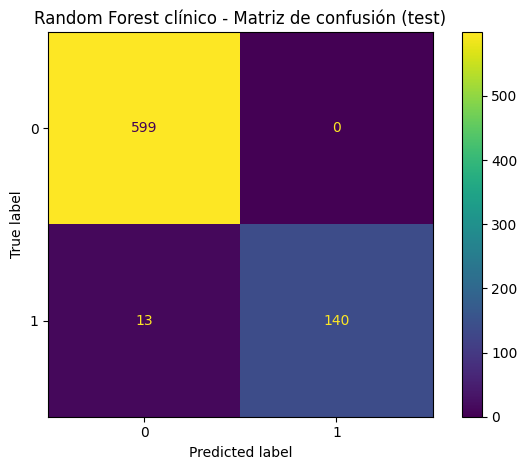

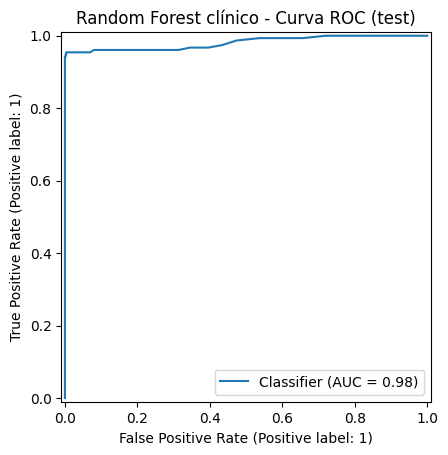

In [3]:
# Predicciones y probabilidades
y_pred_clinico = modelo_rf_clinico.predict(X_test_clinico)
y_proba_clinico = modelo_rf_clinico.predict_proba(X_test_clinico)[:, 1]

# Métricas básicas
acc = accuracy_score(y_test_clinico, y_pred_clinico)
bacc = balanced_accuracy_score(y_test_clinico, y_pred_clinico)
prec = precision_score(y_test_clinico, y_pred_clinico)
rec = recall_score(y_test_clinico, y_pred_clinico)
f1 = f1_score(y_test_clinico, y_pred_clinico)
f1_macro = f1_score(y_test_clinico, y_pred_clinico, average="macro")
auc = roc_auc_score(y_test_clinico, y_proba_clinico)

print(f"Accuracy:          {acc:.4f}")
print(f"Balanced accuracy: {bacc:.4f}")
print(f"Precision:         {prec:.4f}")
print(f"Recall:            {rec:.4f}")
print(f"F1 (binario):      {f1:.4f}")
print(f"F1 macro:          {f1_macro:.4f}")
print(f"AUC ROC:           {auc:.4f}\n")

print("Reporte de clasificación (Random Forest clínico, test):")
print(classification_report(y_test_clinico, y_pred_clinico))

cm = confusion_matrix(y_test_clinico, y_pred_clinico)
print("Matriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot()
plt.title("Random Forest clínico - Matriz de confusión (test)")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_test_clinico, y_proba_clinico)
plt.title("Random Forest clínico - Curva ROC (test)")
plt.show()

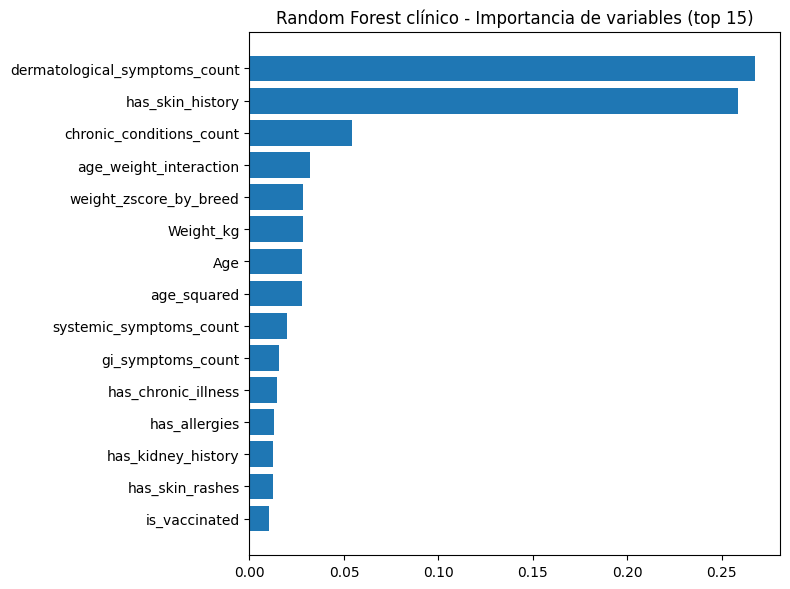

In [4]:
# Importancia de variables (feature_importances_)
importancias = modelo_rf_clinico.feature_importances_
indices_top = np.argsort(importancias)[-15:]  # top 15

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices_top)), importancias[indices_top])
plt.yticks(range(len(indices_top)), [columnas_features[i] for i in indices_top])
plt.title("Random Forest clínico - Importancia de variables (top 15)")
plt.tight_layout()
plt.show()

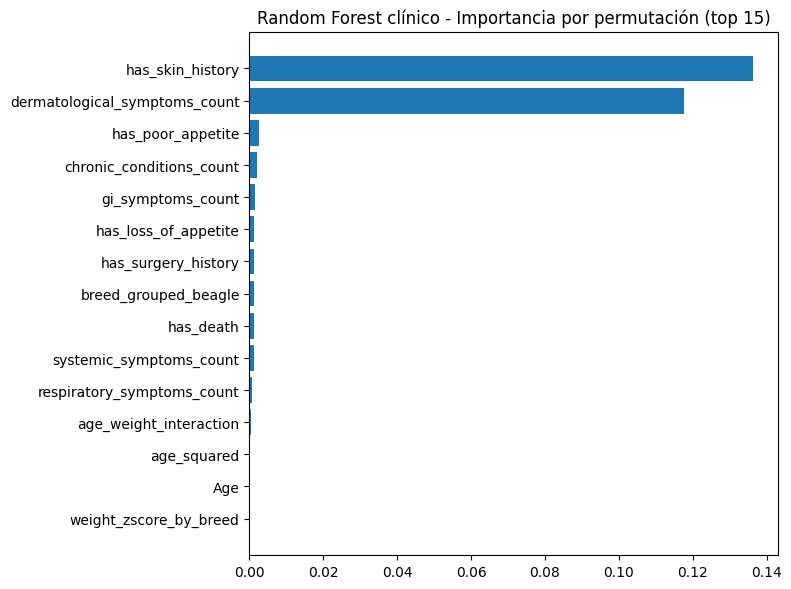

In [5]:
# Importancia por permutación (opcional, puede tardar)
resultado_perm = permutation_importance(
    modelo_rf_clinico,
    X_test_clinico,
    y_test_clinico,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancias_perm = resultado_perm.importances_mean
indices_top_perm = np.argsort(importancias_perm)[-15:]

plt.figure(figsize=(8, 6))
plt.barh(range(len(indices_top_perm)), importancias_perm[indices_top_perm])
plt.yticks(range(len(indices_top_perm)), [columnas_features[i] for i in indices_top_perm])
plt.title("Random Forest clínico - Importancia por permutación (top 15)")
plt.tight_layout()
plt.show()

## 2. Evaluación del modelo de imágenes (CNN EfficientNetB0)

Se evalúa el modelo `modelo_cnn_piel_perros.keras` sobre el conjunto de prueba de imágenes (`datasets/test`). 
Se reportan métricas de clasificación multiclase y se analiza la matriz de confusión para identificar clases que se confunden con mayor frecuencia.


In [6]:
# Cargar modelo de imágenes
modelo_cnn_imagenes = tf.keras.models.load_model(ruta_modelos / "modelo_cnn_piel_perros.keras")

tam_imagen = (224, 224)
tam_lote = 32

# Generador de prueba con el mismo preprocessing que en entrenamiento
datagen_prueba = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

ruta_test_img = ruta_datasets / "test"

datos_prueba_img = datagen_prueba.flow_from_directory(
    ruta_test_img,
    target_size=tam_imagen,
    batch_size=tam_lote,
    class_mode="categorical",
    shuffle=False
)

nombres_clases_img = list(datos_prueba_img.class_indices.keys())
print("Clases de imágenes:", nombres_clases_img)

Found 433 images belonging to 6 classes.
Clases de imágenes: ['Dermatitis', 'Fungal_infections', 'Healthy', 'Hypersensitivity', 'demodicosis', 'ringworm']


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.7909 - loss: 0.5415
Loss (imágenes, test): 0.4461
Accuracy (imágenes, test): 0.8406

14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 348ms/step
Reporte de clasificación (CNN imágenes, test):
                   precision    recall  f1-score   support

       Dermatitis       0.74      0.83      0.79        66
Fungal_infections       0.81      0.48      0.60        54
          Healthy       0.90      0.93      0.91        69
 Hypersensitivity       0.77      0.59      0.67        29
      demodicosis       0.90      0.95      0.92       100
         ringworm       0.84      0.93      0.88       115

         accuracy                           0.84       433
        macro avg       0.83      0.78      0.80       433
     weighted avg       0.84      0.84      0.83       433

Matriz de confusión (CNN imágenes):
[[ 55   1   0   1   2   7]
 [  9  26   5   3   5   6]
 [  0   3  64   1   1   0]
 [  3   2   2  17   1   4]
 [  1   0   0   0  95   4]
 [  6   

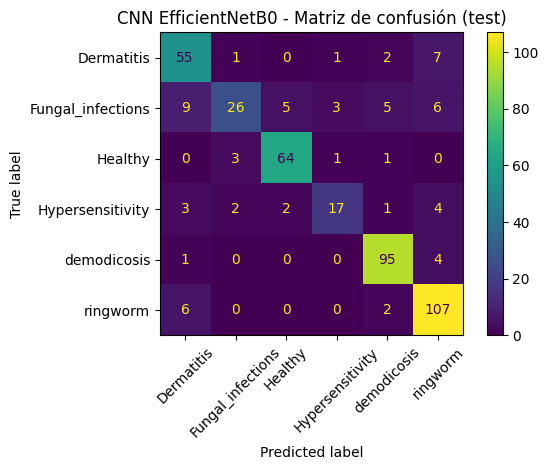

In [7]:
# Evaluación en test
loss_img, acc_img = modelo_cnn_imagenes.evaluate(datos_prueba_img)
print(f"Loss (imágenes, test): {loss_img:.4f}")
print(f"Accuracy (imágenes, test): {acc_img:.4f}\n")

# Predicciones
probas_img = modelo_cnn_imagenes.predict(datos_prueba_img)
y_pred_img = np.argmax(probas_img, axis=1)
y_true_img = datos_prueba_img.classes

print("Reporte de clasificación (CNN imágenes, test):")
print(classification_report(y_true_img, y_pred_img, target_names=nombres_clases_img))

cm_img = confusion_matrix(y_true_img, y_pred_img)
print("Matriz de confusión (CNN imágenes):")
print(cm_img)

disp_img = ConfusionMatrixDisplay(confusion_matrix=cm_img, display_labels=nombres_clases_img)
disp_img.plot(xticks_rotation=45)
plt.title("CNN EfficientNetB0 - Matriz de confusión (test)")
plt.tight_layout()
plt.show()

In [8]:
# AUC macro en configuración multiclase (One-vs-Rest)
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true_img, classes=np.arange(len(nombres_clases_img)))
auc_macro_ovr = roc_auc_score(y_true_bin, probas_img, average="macro", multi_class="ovr")
print(f"AUC macro (OVR, CNN imágenes, test): {auc_macro_ovr:.4f}")

AUC macro (OVR, CNN imágenes, test): 0.9769


Número de errores de clasificación en imágenes: 69


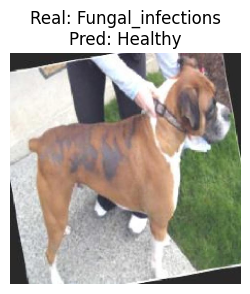

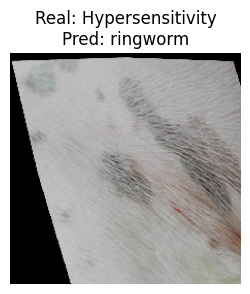

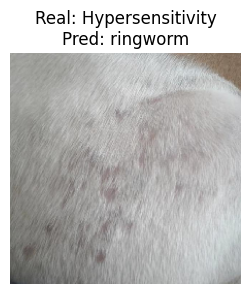

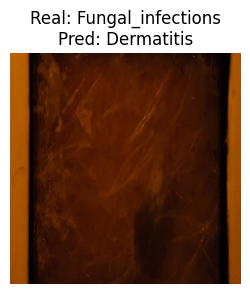

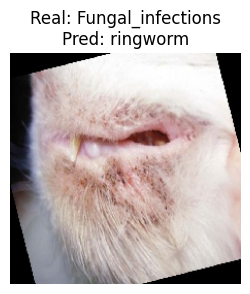

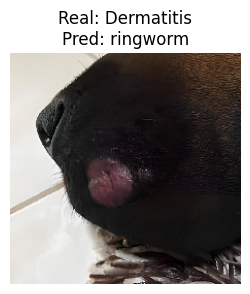

In [9]:
# Visualizar algunos errores de la CNN para identificar confusiones típicas
indices_error = np.where(y_true_img != y_pred_img)[0]
print("Número de errores de clasificación en imágenes:", len(indices_error))

if len(indices_error) > 0:
    n_mostrar = min(6, len(indices_error))
    muestras = np.random.choice(indices_error, size=n_mostrar, replace=False)
    
    for idx in muestras:
        ruta_img = datos_prueba_img.filepaths[idx]
        img = image.load_img(ruta_img, target_size=tam_imagen)
        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Real: {nombres_clases_img[y_true_img[idx]]}\nPred: {nombres_clases_img[y_pred_img[idx]]}")
        plt.show()

Mostrando Grad-CAM para algunas imágenes de prueba:

Índice 2 | Ruta: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets\test\Dermatitis\1000010626_x4_jpg.rf.dd018753531153596ff7da1edd7a61ac.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


c:\Users\Usuario\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\models\functional.py:225: UserWarning: The structure of `inputs` doesn't match the expected structure: ['input_layer_1']. Received: the structure of inputs=*
  warnings.warn(


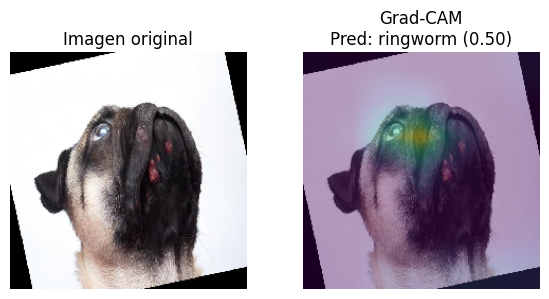


Índice 4 | Ruta: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets\test\Dermatitis\1000010652_x16_jpg.rf.49ca91eb9622ee207a9af19717b70778.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


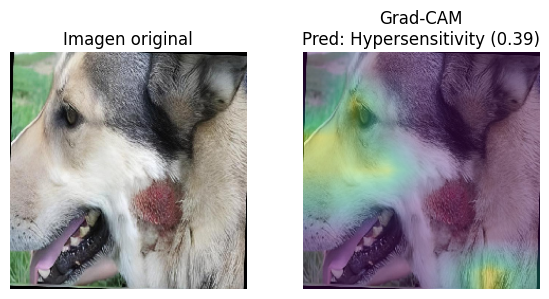


Índice 6 | Ruta: C:\Users\Usuario\Desktop\ESTUDIOS  ARCHIVOS\UPC CICLO 8\MACHINE LEARNING\ML Trabajo Final\SPTMV\datasets\test\Dermatitis\1000010680_x16_jpg.rf.022565ad71fbc7c3f9527a89d399c72a.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


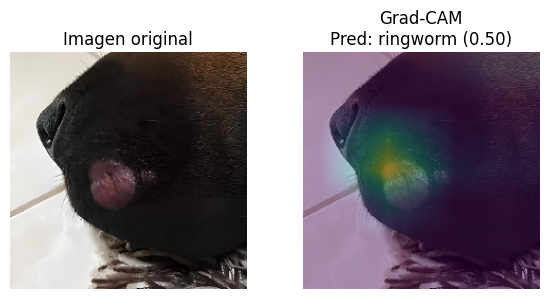

In [14]:
# Grad-CAM sobre algunas imágenes de prueba para interpretar la CNN
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

def generar_gradcam(modelo, img_array, indice_clase, nombre_ultima_capa_conv="top_conv"):
    """
    Genera un mapa Grad-CAM para una imagen y una clase objetivo.

    - modelo: modelo Keras con una capa convolucional final + capa densa.
    - img_array: imagen preprocesada (preprocess_input), shape (224,224,3).
    - indice_clase: índice de la clase objetivo (int).
    - nombre_ultima_capa_conv: nombre de la última capa convolucional del modelo.
      En EfficientNetB0 suele ser 'top_conv'.
    """
    # Asegurarse de que tiene dimensión batch
    img_batch = np.expand_dims(img_array, axis=0)

    # Modelo que devuelve activaciones de la última capa conv + predicciones
    ultima_capa_conv = modelo.get_layer(nombre_ultima_capa_conv)
    grad_model = Model(
        inputs=modelo.inputs,
        outputs=[ultima_capa_conv.output, modelo.output]
    )

    with tf.GradientTape() as tape:
        activaciones_conv, predicciones = grad_model(img_batch)
        salida_clase = predicciones[:, indice_clase]

    # Gradientes de la clase objetivo respecto a la última capa conv
    gradientes = tape.gradient(salida_clase, activaciones_conv)[0]      # (H, W, C)
    activaciones_conv = activaciones_conv[0]                            # (H, W, C)

    # Pesos: media de gradientes sobre spatial dims
    pesos = tf.reduce_mean(gradientes, axis=(0, 1))                     # (C,)

    # Grad-CAM como combinación lineal
    gradcam = tf.reduce_sum(tf.multiply(pesos, activaciones_conv), axis=-1)  # (H, W)

    # Normalizar a [0,1]
    gradcam = tf.maximum(gradcam, 0)
    max_val = tf.reduce_max(gradcam)
    if max_val > 0:
        gradcam = gradcam / max_val

    return gradcam.numpy()

def mostrar_gradcam_sobre_imagen(ruta_img, modelo, nombre_ultima_capa_conv="top_conv", tam_imagen=(224, 224)):
    """
    Carga una imagen de disco, calcula Grad-CAM para la clase predicha por la CNN
    y muestra la imagen original con el mapa superpuesto.
    """
    # Cargar imagen original para visualizar
    img_original = image.load_img(ruta_img, target_size=tam_imagen)
    img_original_arr = image.img_to_array(img_original).astype("uint8")

    # Preprocesar igual que en entrenamiento
    img_array = image.img_to_array(image.load_img(ruta_img, target_size=tam_imagen))
    img_preproc = preprocess_input(img_array.copy())

    # Predicción de la CNN
    probas = modelo.predict(np.expand_dims(img_preproc, axis=0))[0]
    indice_clase_pred = np.argmax(probas)
    nombre_clase_pred = nombres_clases_img[indice_clase_pred]
    proba_clase_pred = probas[indice_clase_pred]

    # Grad-CAM para la clase predicha
    gradcam = generar_gradcam(modelo, img_preproc, indice_clase_pred, nombre_ultima_capa_conv)

    # Redimensionar gradcam a tamaño de imagen
    gradcam_resized = tf.image.resize(gradcam[..., np.newaxis], tam_imagen).numpy().squeeze()

    # Mostrar imagen original y Grad-CAM superpuesto
    plt.figure(figsize=(6, 3))

    plt.subplot(1, 2, 1)
    plt.imshow(img_original_arr.astype("uint8"))
    plt.axis("off")
    plt.title("Imagen original")

    plt.subplot(1, 2, 2)
    plt.imshow(img_original_arr.astype("uint8"))
    plt.imshow(gradcam_resized, alpha=0.4)
    plt.axis("off")
    plt.title(f"Grad-CAM\nPred: {nombre_clase_pred} ({proba_clase_pred:.2f})")

    plt.tight_layout()
    plt.show()

# Seleccionar algunas imágenes de test para visualizar Grad-CAM
# Si ya calculaste 'indices_error' antes, puedes usar errores; si no, muestra aleatorias.
if 'indices_error' in globals() and len(indices_error) > 0:
    indices_mostrar = indices_error[:3]
else:
    indices_mostrar = np.random.choice(len(datos_prueba_img.filepaths), size=3, replace=False)

print("Mostrando Grad-CAM para algunas imágenes de prueba:")
for idx in indices_mostrar:
    ruta_img = datos_prueba_img.filepaths[idx]
    print(f"\nÍndice {idx} | Ruta: {ruta_img}")
    mostrar_gradcam_sobre_imagen(ruta_img, modelo_cnn_imagenes, nombre_ultima_capa_conv="top_conv", tam_imagen=tam_imagen)


## 3. Evaluación del modelo multimodal (ensemble stacking)

Se evalúa el meta-modelo `modelo_multimodal.joblib`, que combina:

- La probabilidad de caso dermatológico del Random Forest clínico (`P_RF(derm)`).
- Las probabilidades por clase de la CNN de imágenes (`P_CNN(clase_i)`).

Para ello se utiliza el dataset multimodal sintético de prueba `multimodal_test.csv`, que contiene las variables clínicas, la columna `target_derm` y la columna `ruta_imagen` con la ruta relativa de la imagen.


In [10]:
# Cargar meta-modelo multimodal
modelo_multimodal = load(ruta_modelos / "modelo_multimodal.joblib")

# Cargar dataset multimodal de prueba
ruta_mm_test = ruta_datasets / "multimodal_test.csv"
df_mm_test = pd.read_csv(ruta_mm_test)

columnas_excluir_mm = ["ruta_imagen", "target_derm"]
columnas_clinicas_mm = [c for c in df_mm_test.columns if c not in columnas_excluir_mm]

X_clinico_mm_test = df_mm_test[columnas_clinicas_mm].values
y_mm_test = df_mm_test["target_derm"].values
rutas_mm_test = df_mm_test["ruta_imagen"].tolist()

print("Tamaño multimodal_test:", df_mm_test.shape)
print("Número de features clínicos:", len(columnas_clinicas_mm))

Tamaño multimodal_test: (752, 74)
Número de features clínicos: 72


In [11]:
def cargar_imagen_procesada_multimodal(ruta_relativa, tam_imagen=(224, 224)):
    """Carga una imagen a partir de una ruta relativa (respecto a 'datasets')
    y aplica el mismo preprocesamiento que en el entrenamiento de la CNN."""
    ruta_img = ruta_datasets / ruta_relativa
    img = image.load_img(ruta_img, target_size=tam_imagen)
    arr = image.img_to_array(img)
    arr = preprocess_input(arr)
    return arr

# Probabilidades clínicas y de la CNN para el split multimodal de test
probas_rf_mm = modelo_rf_clinico.predict_proba(X_clinico_mm_test)[:, 1]
X_img_mm = np.stack([cargar_imagen_procesada_multimodal(r) for r in rutas_mm_test])
probas_cnn_mm = modelo_cnn_imagenes.predict(X_img_mm, batch_size=32)

print("Forma probas RF:", probas_rf_mm.shape)
print("Forma probas CNN:", probas_cnn_mm.shape)

24/24 ━━━━━━━━━━━━━━━━━━━━ 9s 313ms/step
Forma probas RF: (752,)
Forma probas CNN: (752, 6)


In [12]:
# Construir matriz de entrada para el meta-modelo
X_meta_mm_test = np.column_stack([probas_rf_mm, probas_cnn_mm])

# Predicciones del modelo multimodal
y_mm_pred = modelo_multimodal.predict(X_meta_mm_test)
y_mm_proba = modelo_multimodal.predict_proba(X_meta_mm_test)[:, 1]

def resumen_metricas_binarias(nombre, y_true, y_pred, y_proba):
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
        "auc": roc_auc_score(y_true, y_proba)
    }

# Métricas del RF clínico solo (sobre el mismo conjunto multimodal)
y_rf_pred_mm = (probas_rf_mm >= 0.5).astype(int)
res_rf = resumen_metricas_binarias("RF_clinico", y_mm_test, y_rf_pred_mm, probas_rf_mm)

# Métricas del modelo multimodal
res_multi = resumen_metricas_binarias("Multimodal", y_mm_test, y_mm_pred, y_mm_proba)

df_resumen_multi = pd.DataFrame([res_rf, res_multi])
df_resumen_multi

,modelo,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,auc
0,RF_clinico,0.982713,0.957516,1.0,0.915033,0.955631,0.972448,0.980889
1,Multimodal,0.988032,0.970588,1.0,0.941176,0.969697,0.981120,1.000000


Reporte de clasificación (modelo multimodal, test):
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       599
           1       1.00      0.94      0.97       153

    accuracy                           0.99       752
   macro avg       0.99      0.97      0.98       752
weighted avg       0.99      0.99      0.99       752

Matriz de confusión (modelo multimodal):
[[599   0]
 [  9 144]]


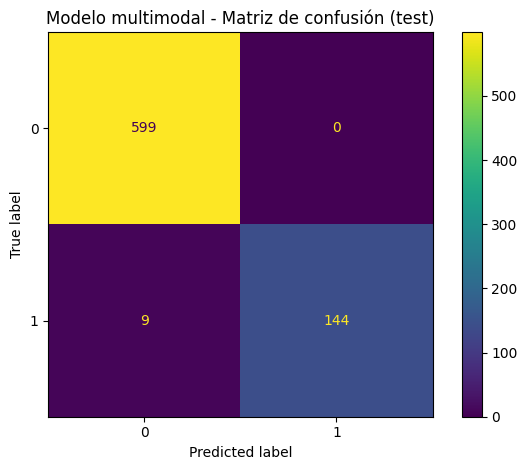

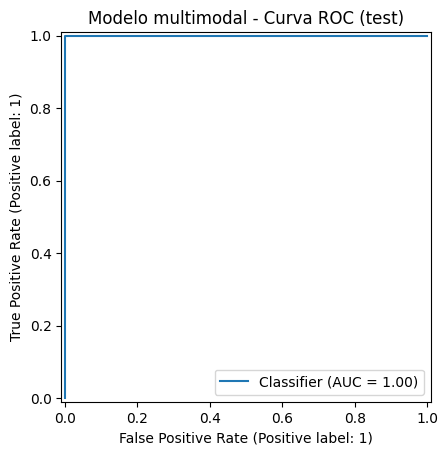

In [13]:
print("Reporte de clasificación (modelo multimodal, test):")
print(classification_report(y_mm_test, y_mm_pred))

cm_mm = confusion_matrix(y_mm_test, y_mm_pred)
print("Matriz de confusión (modelo multimodal):")
print(cm_mm)

disp_mm = ConfusionMatrixDisplay(confusion_matrix=cm_mm, display_labels=[0, 1])
disp_mm.plot()
plt.title("Modelo multimodal - Matriz de confusión (test)")
plt.tight_layout()
plt.show()

RocCurveDisplay.from_predictions(y_mm_test, y_mm_proba)
plt.title("Modelo multimodal - Curva ROC (test)")
plt.show()